# Tutorial 3: Model Diagnosis

After training, the key question is: **did the model learn cell-type-specific regulatory patterns?**

The most important diagnostic is whether cells cluster by type in the model's latent spaces. As the original deepSCENIC author put it: *"First I take a look at enhancer and predicted RNA embeddings. If cell types are nicely clustered, that's a good sign."*

This tutorial shows how to check if your model learned meaningful biology.

## Setup

In [1]:
import torch
import scanpy as sc

import deepscenic as ds

print(f"deepSCENIC version: {ds.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

deepSCENIC version: 0.1.0
Using device: cuda


## Load Model and Data

We load the preprocessed MuData (which should include cell annotations from Tutorial 1) and the trained model.

In [2]:
import os

data_dir = "../../../../data/deepSCENIC/MM_lines/"
assert os.path.exists(data_dir), "Data directory not found"

# Load preprocessed MuData
mdata = ds.read(data_dir + "preprocessed_data.h5mu")

# Load trained model
model = ds.tl.load_model(data_dir + "weights/converted_model.pt", device=device)

# Verify cell annotations are available (if you have them)
print(f"\nCell annotations: {list(mdata.obs.columns)}")
if "cell_state" in mdata.obs:
    print(f"Cell states: {mdata.obs['cell_state'].value_counts().to_dict()}")

deepscenic.io - INFO - Loaded ../../../../data/deepSCENIC/MM_lines/preprocessed_data.h5mu: 936 cells, 12156 genes, 281820 regions
deepscenic.tl - INFO - Loaded model from ../../../../data/deepSCENIC/MM_lines/weights/converted_model.pt: 11717 genes, 1386 TFs, 273545 regions



Cell annotations: ['cell_line', 'cell_state', 'split']
Cell states: {'INT': 358, 'MEL': 318, 'MES': 260}


## Extract Model Embeddings

The model produces several intermediate representations that we can visualize:

- **z_tf**: Latent TF activity (after the encoder)
- **enh_act**: Enhancer/region activity (z_tf multiplied by E1)
- **z_rna**: Predicted gene regulatory signal (enh_act multiplied by E2)

Each of these should show cell-type-specific structure if the model learned well.

In [3]:
# Extract all embeddings in one pass
embeddings = ds.tl.to_latent(model, mdata)

print("Extracted embeddings:")
for name, arr in embeddings.items():
    print(f"  {name}: {arr.shape}")

Extracting embeddings:   0%|          | 0/4 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 3.06 GiB. GPU 0 has a total capacity of 7.66 GiB of which 1.39 GiB is free. Including non-PyTorch memory, this process has 6.09 GiB memory in use. Of the allocated memory 5.85 GiB is allocated by PyTorch, and 89.44 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Cell-Type Clustering in Latent Spaces

The primary diagnostic: **do cells cluster by type in the model's embedding spaces?**

If cells with the same annotation (e.g., cell state) cluster together, the model has learned biologically meaningful patterns. If cells are randomly mixed, something went wrong.

### TF Activity Space (z_tf)

This is the most direct test of whether the model learned TF activity patterns that distinguish cell types.

/home/luna.kuleuven.be/u0166574/.local/share/hatch/env/virtual/deepscenic/5tHRoqxA/docs/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


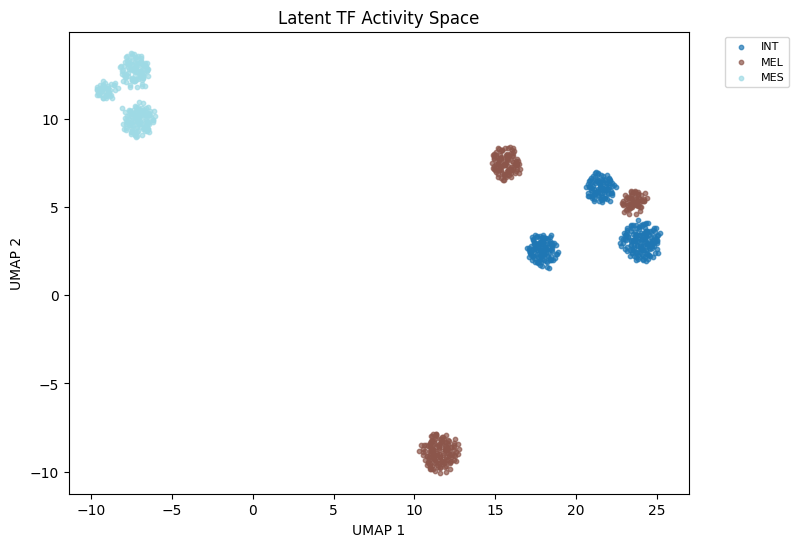

In [4]:
# UMAP of TF activity space
# The built-in function handles UMAP computation and plotting
ds.pl.latent_umap(
    model, 
    mdata, 
    color="cell_state"
)

### Predicted Gene Expression Space (z_rna)

This tests whether the full regulatory cascade (TF → region → gene) captures cell identity. The z_rna embedding is ~12k dimensional, so we use PCA followed by UMAP.

In [5]:
# Create an AnnData to use scanpy's UMAP functions
adata_rna = sc.AnnData(embeddings["z_rna"])
adata_rna.obs = mdata.obs.copy()

# PCA -> neighbors -> UMAP
sc.pp.pca(adata_rna, n_comps=50)
sc.pp.neighbors(adata_rna, n_neighbors=15)
sc.tl.umap(adata_rna)

sc.pl.umap(adata_rna, color="cell_state", title="Predicted Gene Expression (z_rna)")

NameError: name 'embeddings' is not defined

### Enhancer Activity Space (enh_act) - Optional

The enhancer activity embedding is high-dimensional (~280k regions), so this takes longer to compute. It shows whether cells cluster based on their regulatory region activity patterns.

```{note}
This step is optional. If z_tf and z_rna show good clustering, you can skip this.
```

In [6]:
# UMAP of enhancer activity (requires PCA due to high dimensionality)
adata_enh = sc.AnnData(embeddings["enh_act"])
adata_enh.obs = mdata.obs.copy()

sc.pp.pca(adata_enh, n_comps=50)
sc.pp.neighbors(adata_enh, n_neighbors=15)
sc.tl.umap(adata_enh)

sc.pl.umap(adata_enh, color="cell_state", title="Enhancer Activity (enh_act)")

NameError: name 'embeddings' is not defined

### Interpreting the Clustering

**Good signs:**
- Distinct clusters that match your cell state annotations (MEL, MES, INT)
- Consistent clustering across all three spaces (z_tf, z_rna, enh_act)
- Intermediate states (like INT) appearing between major clusters

**Bad signs:**
- Random mixing of cell types
- No visible structure
- Only seeing batch effects (if you have multiple batches)

## Training Curves (Secondary Check)

If you trained the model yourself (rather than loading a converted legacy model), you can check the training curves:

```python
# Only available for models trained with ds.tl.train()
ds.pl.loss_curves(model)
```

Look for: decreasing loss, train/test curves that don't diverge wildly.

## TF Activity Profiles (Optional Deep Dive)

Once you've confirmed good clustering, you can examine which TFs drive the cell-type differences with a clustered heatmap.

/home/luna.kuleuven.be/u0166574/Desktop/projects/deepSCENIC/src/deepscenic/pl/training/_diagnostics.py:590: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df_tf.groupby(groups).mean().T


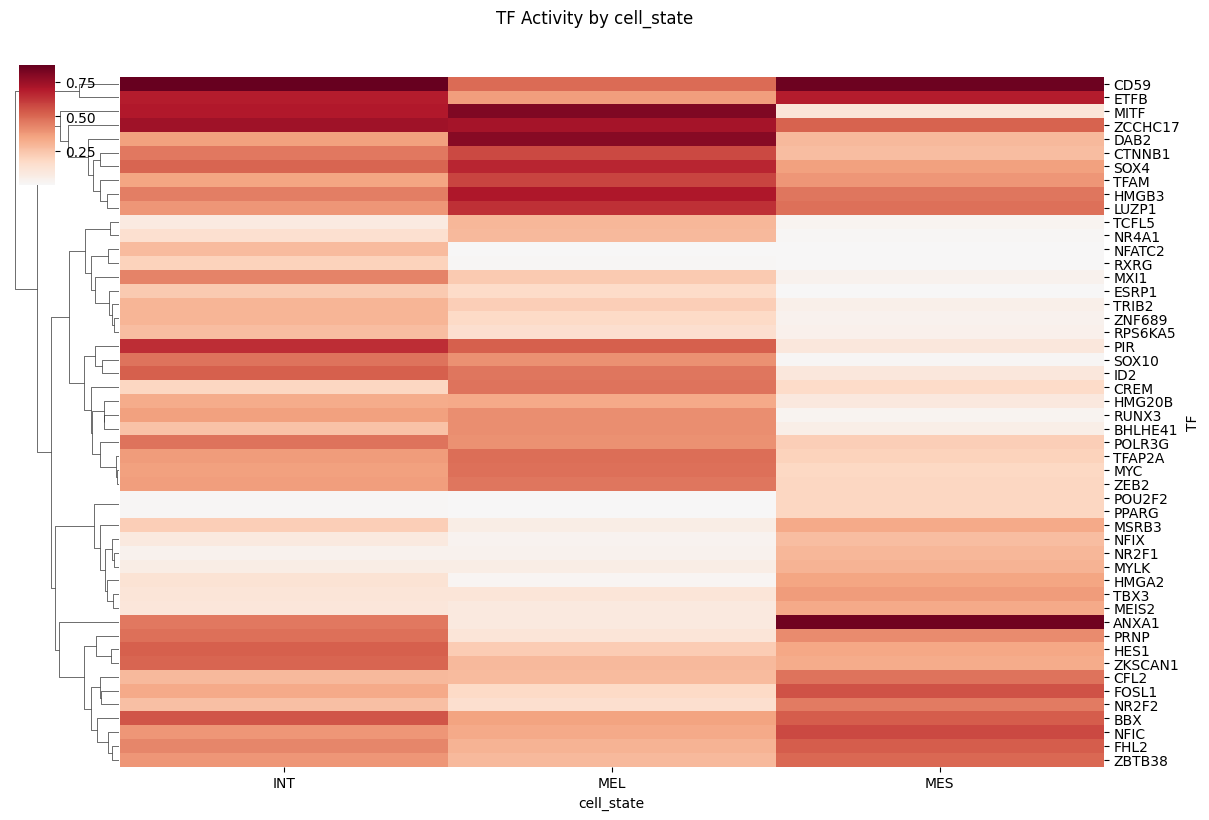

In [7]:
# Show top 50 most variable TFs across cell states
ds.pl.tf_activity_clustermap(model, mdata, groupby="cell_state", top_n_tfs=50)